In [1]:
import numpy as np
from triangular_transport.flows.methods.utils import UnitGaussianNormalizer
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2
import h5py

In [2]:
ys = np.load("training_dataset/solutions_delta.npy")
us = np.load("training_dataset/parameters_delta.npy")

In [3]:
ys[0] # This is telling us that the first observation in the dataset that we generate will be the first conditioning variable used in the convergence analysis!!!!!

array([ 0.00757862, -0.00093028, -0.02486473, -0.03709776, -0.03374963,
       -0.01521817,  0.02303982,  0.03867096,  0.03566536,  0.01609342,
        0.01033251, -0.01506351, -0.06153487, -0.09428737, -0.08010361,
       -0.03202915,  0.03515198,  0.08749991,  0.08335609,  0.03158481,
       -0.00443926, -0.04386323, -0.09545473, -0.13016372, -0.11129163,
       -0.0476241 ,  0.0218867 ,  0.08270327,  0.08987164,  0.0353934 ,
       -0.02494915, -0.07891167, -0.134035  , -0.1672698 , -0.13926499,
       -0.07902726, -0.01024771,  0.04985435,  0.06710143,  0.02826236,
       -0.03558701, -0.09985587, -0.15559136, -0.1909895 , -0.15989581,
       -0.10135178, -0.04229917,  0.00921256,  0.03187895,  0.02186022,
       -0.0361001 , -0.09785106, -0.14581445, -0.17308454, -0.14537376,
       -0.09773422, -0.05633489, -0.02213609, -0.00223596,  0.01267492,
       -0.02888419, -0.07946463, -0.11596771, -0.1289629 , -0.10272226,
       -0.06403577, -0.03727732, -0.02155183, -0.01052665,  0.00

In [4]:
ys_mean = np.mean(ys, axis=0)
ys_std = np.std(ys, axis=0)

ys_98 = norm.ppf(0.98, loc=ys_mean, scale=ys_std)
ys_68 = norm.ppf(0.68, loc=ys_mean, scale=ys_std)

cov = np.cov(ys, rowvar=False)
inv_cov = np.linalg.inv(cov)

def mahal_square(y):
    diff = y - ys_mean
    return diff.T @ inv_cov @ diff

mahal = mahal_square(ys[0])

In [5]:
p = chi2.cdf(mahal, df=ys.shape[1])
p

np.float64(0.6867540988314857)

The variable $p$ is basically saying that $y_{\mathrm{obs}}$ lies on an ellipsoid that contains a fraction $p$ of the Gaussian mass. So it's really similar to a quantile, though it isn't quite the same. It is the exact Gaussian quantile of the Mahalanobis distance. The reason why this is hard to interpret is because the y's are multivariate so it's impossible to get a unique notion of quantile.

In [6]:
diff = ys - ys_mean
mahal_all = np.sum(diff @ inv_cov * diff, axis=1)

In [7]:
mahal_all

array([106.34861212, 101.39494423,  94.25007524, ..., 101.88810308,
       129.10881632,  78.38326073], shape=(250000,))

In [8]:
q98 = np.quantile(mahal_all, 0.90) # NOTE: This actually corresponds to the 90th percentile!!!!!!
idx_closest = np.argmin(np.abs(mahal_all - q98))
y_98 = ys[idx_closest]
y_98

array([-0.00715207, -0.00502559,  0.01603702,  0.02934951,  0.03521678,
        0.03445777,  0.02493957,  0.00701597, -0.01479284, -0.01216737,
       -0.01807945, -0.00980157,  0.02560915,  0.06282984,  0.09160004,
        0.09131353,  0.06495303,  0.02706535, -0.00798245, -0.01146392,
       -0.01562169, -0.01309017,  0.02617815,  0.07221399,  0.11848162,
        0.12123252,  0.07665648,  0.02876298, -0.00926625, -0.00869436,
       -0.01974234, -0.01386113,  0.03573256,  0.09288694,  0.13378338,
        0.11893263,  0.06902503,  0.01696375, -0.01569113, -0.00929946,
       -0.01934491, -0.00593007,  0.04863204,  0.10336149,  0.13398891,
        0.11037642,  0.06525366,  0.0265225 ,  0.00212923, -0.0058217 ,
       -0.02235096, -0.00899921,  0.03774949,  0.08027052,  0.0994072 ,
        0.09749868,  0.07657688,  0.05319731,  0.03350864,  0.00972963,
       -0.02539729, -0.01669681,  0.01541275,  0.03597793,  0.04558531,
        0.05412321,  0.05496493,  0.06390128,  0.0594831 ,  0.02

In [9]:
idx_closest

np.int64(132446)

In [10]:
np.save("data_98.npy", y_98)

Do the same for the median below, following the exact steps from the above

In [11]:
q50 = np.quantile(mahal_all, 0.50)
idx_closest = np.argmin(np.abs(mahal_all - q50))
y_50 = ys[idx_closest]
y_50

array([-0.02383011, -0.0435136 , -0.04896687, -0.04269988, -0.03271456,
       -0.02452217, -0.0213205 , -0.01391941, -0.00112087,  0.01088469,
       -0.04031749, -0.10021937, -0.12205131, -0.10990547, -0.08342423,
       -0.04708163, -0.02011875, -0.01178417,  0.00674696,  0.01520986,
       -0.03520016, -0.10107152, -0.13800891, -0.13150036, -0.08589502,
       -0.02906993,  0.01691314,  0.03549095,  0.0420051 ,  0.01886407,
       -0.01805836, -0.06353727, -0.09827759, -0.09658093, -0.05751604,
       -0.00255021,  0.05078865,  0.08131547,  0.07046262,  0.02602014,
        0.01152283, -0.01239629, -0.04193815, -0.04823037, -0.0231544 ,
        0.01849234,  0.06935775,  0.10420268,  0.08323705,  0.02849861,
        0.02359017,  0.03379391,  0.01107127, -0.00058298,  0.01164457,
        0.03529001,  0.07285357,  0.10177439,  0.07947758,  0.03004361,
        0.02927822,  0.06465477,  0.05077366,  0.0418015 ,  0.04912404,
        0.06089116,  0.07290667,  0.08391166,  0.06717311,  0.02

In [12]:
idx_closest

np.int64(24439)

In [13]:
np.save("data_50.npy", y_50)

In [14]:
np.save("data_obs.npy", ys[0])

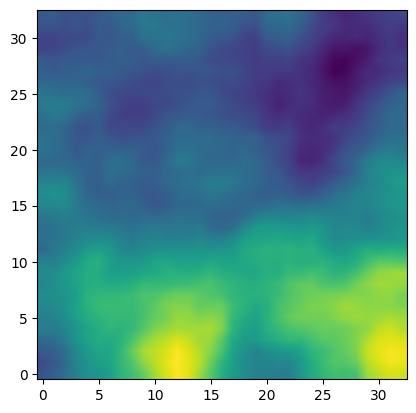

In [20]:
plt.imshow(us[idx_closest].reshape(33, 33), origin="lower", interpolation="bilinear")

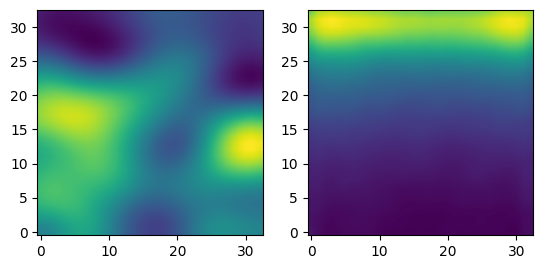

In [15]:
import numpy as np
import matplotlib.pyplot as plt

u_samps0 = np.load("mcmc_98/chain_30/hmala_samples.npy")
u_mean0 = np.mean(u_samps0, axis=0)
u_var0 = np.var(u_samps0, axis=0)
fig, ax = plt.subplots(1, 2)

ax[0].imshow(u_mean0.reshape(33, 33), origin="lower", interpolation="bilinear")
ax[1].imshow(u_var0.reshape(33, 33), origin="lower", interpolation="bilinear")

In [7]:
u_samps0.shape

(47000, 1089)

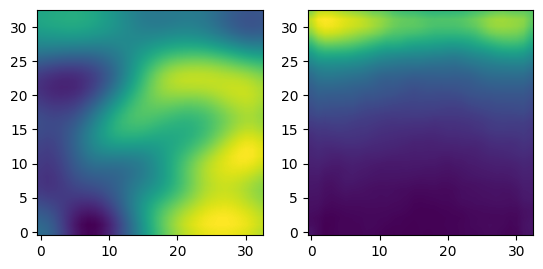

In [2]:
import numpy as np
import matplotlib.pyplot as plt

u_samps0 = np.load("mcmc_median/chain_00/hmala_samples.npy")
u_mean0 = np.mean(u_samps0, axis=0)
u_var0 = np.var(u_samps0, axis=0)
fig, ax = plt.subplots(1, 2)

ax[0].imshow(u_mean0.reshape(33, 33), origin="lower", interpolation="bilinear")
ax[1].imshow(u_var0.reshape(33, 33), origin="lower", interpolation="bilinear")

In [1]:
import numpy as np
B = np.array([[3, 2],
             [1, 4]])
cov = np.array([[0.0004, 0.001],
                [0.001, 0.0025]])
B @ cov @ B.T

array([[0.0256, 0.0352],
       [0.0352, 0.0484]])

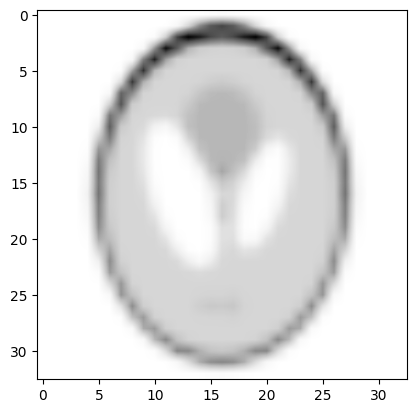

In [9]:
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
import matplotlib.pyplot as plt

phantom = shepp_logan_phantom()
nx = ny = 33
phantom_resized = resize(phantom, (nx, ny), anti_aliasing=True)
m_min, m_max = -3.0, 3.0
p = phantom_resized
p_norm = (p - p.min()) / (p.max() - p.min())  # normalize to [0,1]
m_true_array = m_min + p_norm * (m_max - m_min)
plt.imshow(m_true_array, cmap="Greys", interpolation="bilinear")

In [10]:
m_true_array

array([[-3., -3., -3., ..., -3., -3., -3.],
       [-3., -3., -3., ..., -3., -3., -3.],
       [-3., -3., -3., ..., -3., -3., -3.],
       ...,
       [-3., -3., -3., ..., -3., -3., -3.],
       [-3., -3., -3., ..., -3., -3., -3.],
       [-3., -3., -3., ..., -3., -3., -3.]], shape=(33, 33))

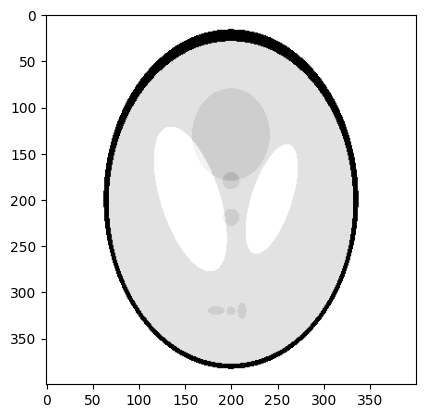

In [7]:
plt.imshow(phantom, cmap="Greys")

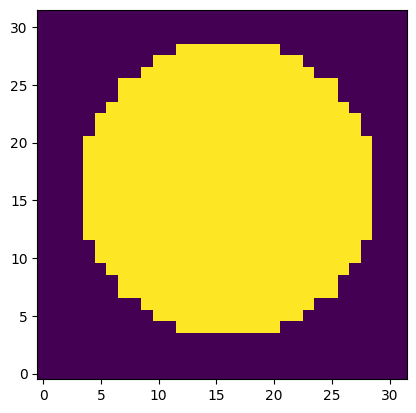

In [8]:
import numpy as np
import matplotlib.pyplot as plt
def circle_phantom(n=256, radius=0.8, center=None, value=np.log(20.0)):
    if center is None:
        center = (n/2, n/2)

    y, x = np.ogrid[:n, :n]
    cx, cy = center
    r_pix = radius * (n/2)

    mask = (x - cx)**2 + (y - cy)**2 <= r_pix**2
    img = np.zeros((n, n), dtype=float)
    img[mask] = value
    img[~mask] = np.log(3.0)
    return img
plt.imshow(circle_phantom(32), origin="lower")

In [9]:
np.unique(circle_phantom(32))

array([1.09861229, 2.99573227])